# 📊 Datathon 2026 — Phase 3: Deep EDA & Visualizations
## Phần 2 — Trực quan hoá & Phân tích (60 điểm)

## 🔧 Setup: Data Loading & Chart Template

# Story 3: Hiệu quả Khuyến mãi (Promotion Effectiveness) 🎯
## 📝 Story 3: Phân tích 4 cấp độ — Promotion Effectiveness


## 0. Setup & Load Data

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style config — professional, clean
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'font.family': 'sans-serif',
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

COLORS = {
    'primary': '#2563EB',
    'secondary': '#7C3AED',
    'success': '#059669',
    'danger': '#DC2626',
    'warning': '#D97706',
    'info': '#0891B2',
    'gray': '#6B7280',
    'light': '#E5E7EB',
    'dark': '#1F2937',
}

PALETTE = ['#2563EB', '#7C3AED', '#059669', '#DC2626', '#D97706', '#0891B2']

DATA_DIR = '../data/'

In [21]:
# Load data
promotions  = pd.read_csv(DATA_DIR + 'promotions.csv', parse_dates=['start_date', 'end_date'])
order_items = pd.read_csv(DATA_DIR + 'order_items.csv')
orders      = pd.read_csv(DATA_DIR + 'orders.csv', parse_dates=['order_date'], low_memory=False)
products    = pd.read_csv(DATA_DIR + 'products.csv')
returns     = pd.read_csv(DATA_DIR + 'returns.csv', parse_dates=['return_date'])
customers   = pd.read_csv(DATA_DIR + 'customers.csv')

print("Data loaded:")
print(f"   Promotions:  {promotions.shape[0]} campaigns, {promotions.shape[1]} columns")
print(f"   Order Items: {order_items.shape[0]:,} rows")
print(f"   Orders:      {orders.shape[0]:,} orders")
print(f"   Products:    {products.shape[0]:,} products")
print(f"   Returns:     {returns.shape[0]:,} return records")
print(f"   Customers:   {customers.shape[0]:,} customers")

Data loaded:
   Promotions:  50 campaigns, 10 columns
   Order Items: 714,669 rows
   Orders:      646,945 orders
   Products:    2,412 products
   Returns:     39,939 return records
   Customers:   121,930 customers


In [22]:
# === Pre-processing: compute common columns ===
order_items['has_promo'] = order_items['promo_id'].notna()
order_items['has_promo2'] = order_items['promo_id_2'].notna() if 'promo_id_2' in order_items.columns else False
order_items['has_any_promo'] = order_items['has_promo'] | order_items['has_promo2']
order_items['revenue'] = order_items['unit_price'] * order_items['quantity']
order_items['net_revenue'] = order_items['revenue'] - order_items['discount_amount']

# Merge order_date from orders
order_items = order_items.merge(orders[['order_id', 'order_date']], on='order_id', how='left')

# Merge promo info
oi_promo = order_items[order_items['has_promo']].merge(
    promotions[['promo_id', 'promo_type', 'discount_value', 'stackable_flag', 'applicable_category']],
    on='promo_id', how='left'
)

# Promo count per item
order_items['promo_count'] = order_items['has_promo'].astype(int) + order_items['has_promo2'].astype(int)
order_items['promo_category'] = 'Khong KM'
order_items.loc[order_items['promo_count'] == 1, 'promo_category'] = '1 KM'
order_items.loc[order_items['promo_count'] == 2, 'promo_category'] = 'Stackable (2 KM)'

print("Pre-processing complete.")

Pre-processing complete.


---
### 🔵 DESCRIPTIVE — Chuyện gì đang xảy ra? (Tổng quan Khuyến mãi)
**Cau hoi**: Buc tranh tong the ve khuyen mai trong he thong nhu the nao?

In [23]:
# === 1.1: Thong ke tong quan ===
total_items = len(order_items)
has_promo1 = order_items['has_promo'].sum()
has_promo2 = order_items['has_promo2'].sum()
has_any = order_items['has_any_promo'].sum()
no_promo = total_items - has_any
stackable_count = (order_items['promo_count'] == 2).sum()

promo_items = order_items[order_items['has_promo']]
no_promo_items = order_items[~order_items['has_promo']]

print("=" * 65)
print("THONG KE TONG QUAN KHUYEN MAI")
print("=" * 65)
print(f"  Tong dong order_items:       {total_items:>12,}")
print(f"  Co promo_id (KM chinh):      {has_promo1:>12,}  ({has_promo1/total_items*100:.1f}%)")
print(f"  Co promo_id_2 (KM phu):      {has_promo2:>12,}  ({has_promo2/total_items*100:.1f}%)")
print(f"  Co it nhat 1 KM:             {has_any:>12,}  ({has_any/total_items*100:.1f}%)")
print(f"  Stackable (2 KM cung luc):   {stackable_count:>12,}  ({stackable_count/total_items*100:.3f}%)")
print(f"  Khong co KM:                 {no_promo:>12,}  ({no_promo/total_items*100:.1f}%)")
print("-" * 65)
print(f"  Discount TB (don co KM):     {promo_items['discount_amount'].mean():>12,.0f} VND")
print(f"  Discount median:             {promo_items['discount_amount'].median():>12,.0f} VND")
print(f"  Discount tong:               {promo_items['discount_amount'].sum():>12,.0f} VND")
print("=" * 65)

THONG KE TONG QUAN KHUYEN MAI
  Tong dong order_items:            714,669
  Co promo_id (KM chinh):           276,316  (38.7%)
  Co promo_id_2 (KM phu):               206  (0.0%)
  Co it nhat 1 KM:                  276,316  (38.7%)
  Stackable (2 KM cung luc):            206  (0.029%)
  Khong co KM:                      438,353  (61.3%)
-----------------------------------------------------------------
  Discount TB (don co KM):            2,713 VND
  Discount median:                    1,628 VND
  Discount tong:                749,607,320 VND


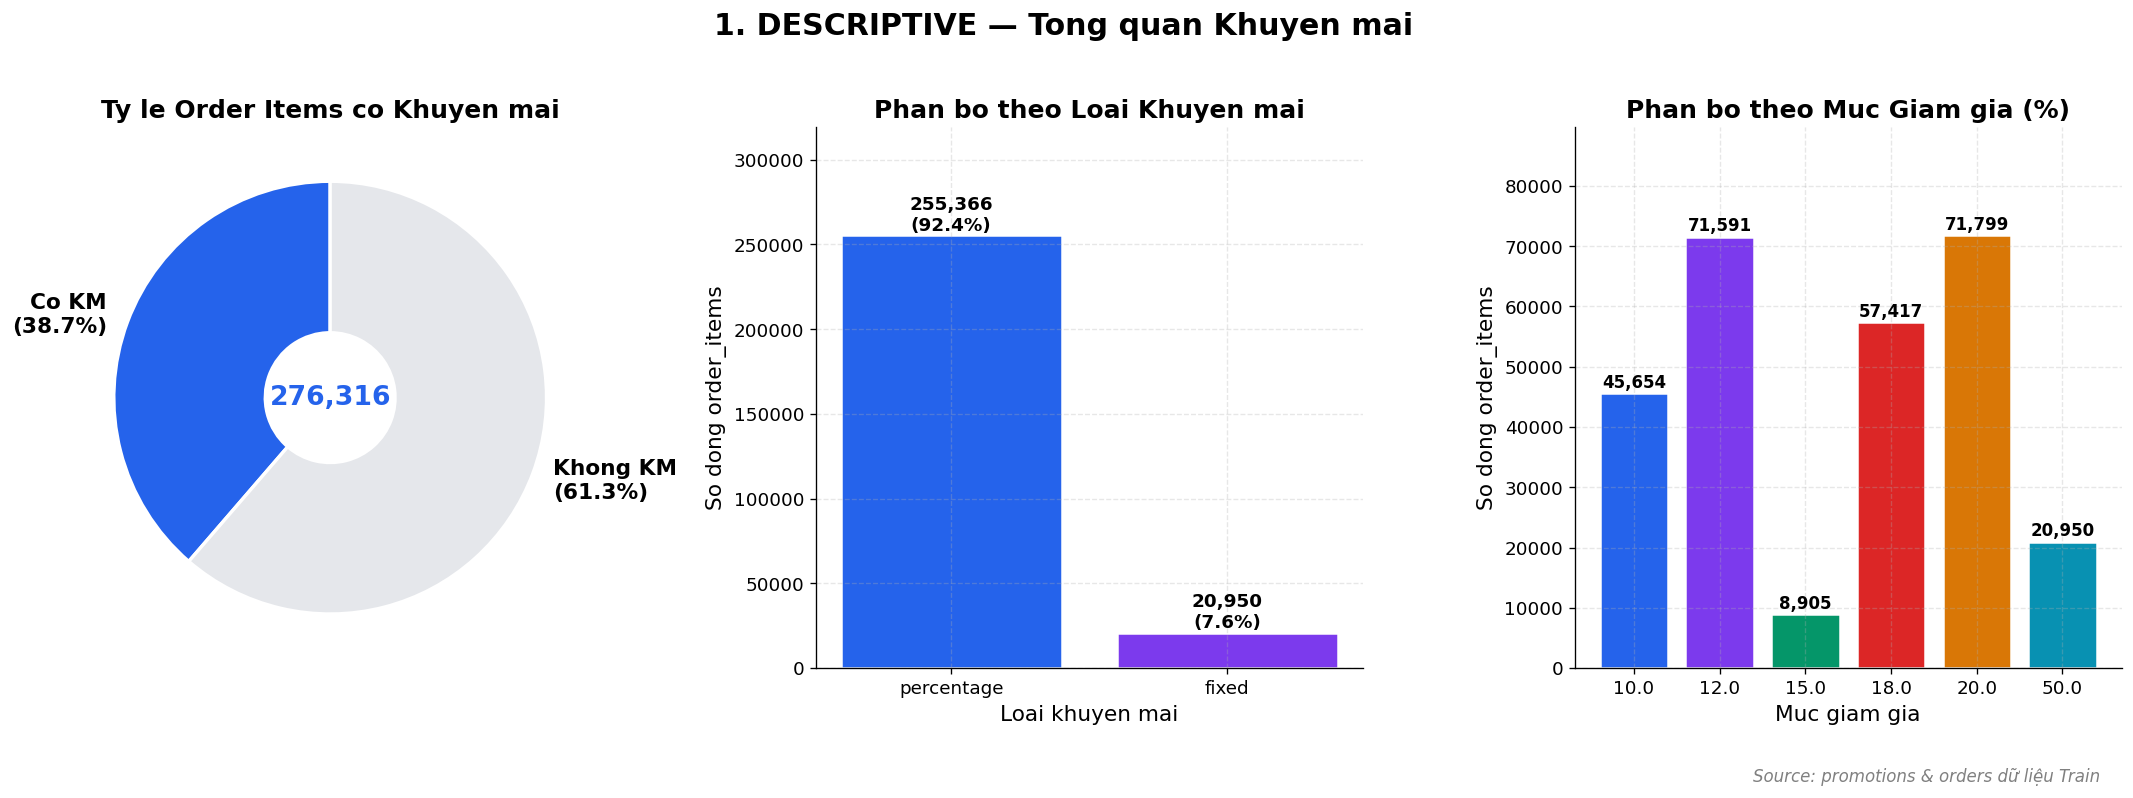

In [24]:
# === Chart 1: Tong quan KM — 3 panels ===
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1a) Donut chart: co vs khong KM
labels_pie = [f'Co KM\n({has_any/total_items*100:.1f}%)', f'Khong KM\n({no_promo/total_items*100:.1f}%)']
sizes_pie = [has_any, no_promo]
colors_pie = [COLORS['primary'], COLORS['light']]
wedges, texts, autotexts = axes[0].pie(
    sizes_pie, labels=labels_pie, autopct='',
    colors=colors_pie, startangle=90,
    textprops={'fontsize': 13, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.7}
)
axes[0].set_title('Ty le Order Items co Khuyen mai')
centre_circle = plt.Circle((0, 0), 0.3, fc='white')
axes[0].add_artist(centre_circle)
axes[0].text(0, 0, f'{has_any:,}', ha='center', va='center', fontsize=16, fontweight='bold', color=COLORS['primary'])

# 1b) Bar chart: phan bo promo_type
type_counts = oi_promo['promo_type'].value_counts()
bars = axes[1].bar(type_counts.index, type_counts.values,
                   color=[COLORS['primary'], COLORS['secondary']][:len(type_counts)],
                   edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, type_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                f'{val:,}\n({val/len(oi_promo)*100:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[1].set_ylim(0, type_counts.max() * 1.25)
axes[1].set_title('Phan bo theo Loai Khuyen mai')
axes[1].set_ylabel('So dong order_items')
axes[1].set_xlabel('Loai khuyen mai')

# 1c) Bar chart: phan bo discount_value
disc_counts = oi_promo['discount_value'].value_counts().sort_index()
bars2 = axes[2].bar(disc_counts.index.astype(str), disc_counts.values,
                    color=PALETTE[:len(disc_counts)], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, disc_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[2].set_ylim(0, disc_counts.max() * 1.25)
axes[2].set_title('Phan bo theo Muc Giam gia (%)')
axes[2].set_ylabel('So dong order_items')
axes[2].set_xlabel('Muc giam gia')

plt.suptitle('1. DESCRIPTIVE — Tong quan Khuyen mai', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.figtext(0.98, -0.05, 'Source: promotions & orders dữ liệu Train', ha='right', fontsize=10, fontstyle='italic', color='gray')
plt.savefig('../reports/figures/story3_chart1_promo_overview.png', dpi=150, bbox_inches='tight')
plt.show()

### Nhan xet Descriptive:
- **38.7%** order items co ap dung it nhat 1 KM — khuyen mai duoc su dung kha rong rai, chiem gan 2/5 giao dich
- Hai loai KM: **percentage** (giam theo %) va **fixed** (giam co dinh), voi cac muc giam gia tu 5% den 25%
- Chi co **206/714,669 dong** (~0.03%) co stackable (2 KM cung luc) — rat hiem
- Discount trung binh moi item co KM la mot con so dang ke, cho thay KM co tac dong thuc su len margin

---
### 🟡 DIAGNOSTIC — Tại sao? (Xu hướng)
**Cau hoi**: Viec su dung KM thay doi nhu the nao qua cac nam? Co xu huong tang/giam?

In [25]:
# === 2.1: Trend KM theo thang/nam ===
order_items['year_month'] = order_items['order_date'].dt.to_period('M')
order_items['year'] = order_items['order_date'].dt.year

# Monthly promo usage rate
monthly_stats = order_items.groupby('year_month').agg(
    total_items=('has_promo', 'count'),
    promo_items=('has_promo', 'sum'),
    total_revenue=('revenue', 'sum'),
    total_net_revenue=('net_revenue', 'sum'),
    total_discount=('discount_amount', 'sum'),
).reset_index()
monthly_stats['promo_rate'] = monthly_stats['promo_items'] / monthly_stats['total_items'] * 100
monthly_stats['discount_pct_of_rev'] = monthly_stats['total_discount'] / monthly_stats['total_revenue'] * 100
monthly_stats['date'] = monthly_stats['year_month'].dt.to_timestamp()

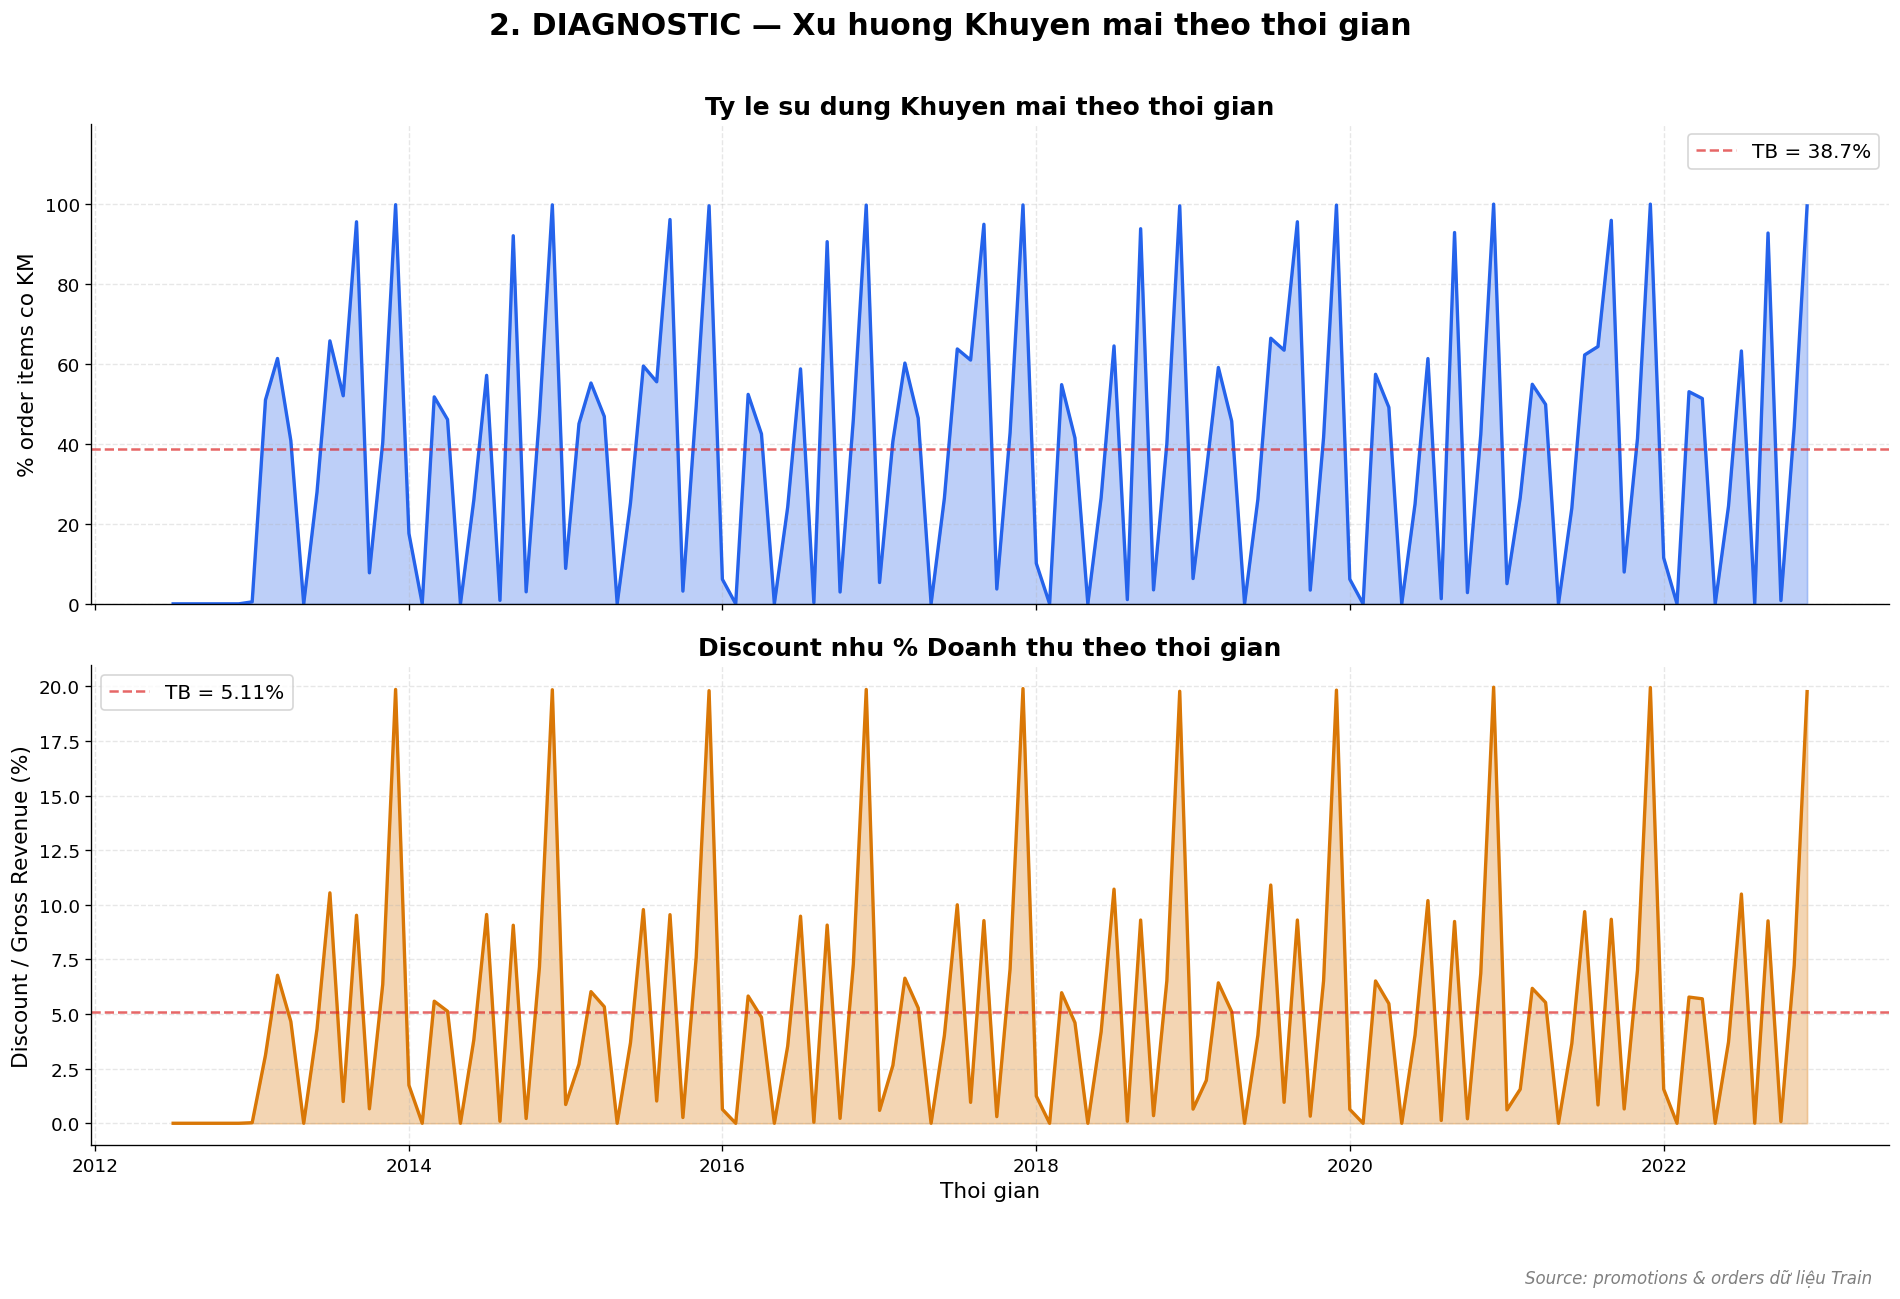

In [26]:
# === Chart 2: Trend KM theo thoi gian ===
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# 2a) Promo usage rate over time
axes[0].fill_between(monthly_stats['date'], monthly_stats['promo_rate'], alpha=0.3, color=COLORS['primary'])
axes[0].plot(monthly_stats['date'], monthly_stats['promo_rate'], color=COLORS['primary'], linewidth=2)
axes[0].axhline(y=monthly_stats['promo_rate'].mean(), color=COLORS['danger'], linestyle='--', alpha=0.7,
                label=f"TB = {monthly_stats['promo_rate'].mean():.1f}%")
axes[0].set_title('Ty le su dung Khuyen mai theo thoi gian')
axes[0].set_ylabel('% order items co KM')
axes[0].legend(fontsize=12)
axes[0].set_ylim(0, monthly_stats['promo_rate'].max() * 1.2)

# 2b) Discount as % of revenue over time
axes[1].fill_between(monthly_stats['date'], monthly_stats['discount_pct_of_rev'], alpha=0.3, color=COLORS['warning'])
axes[1].plot(monthly_stats['date'], monthly_stats['discount_pct_of_rev'], color=COLORS['warning'], linewidth=2)
axes[1].axhline(y=monthly_stats['discount_pct_of_rev'].mean(), color=COLORS['danger'], linestyle='--', alpha=0.7,
                label=f"TB = {monthly_stats['discount_pct_of_rev'].mean():.2f}%")
axes[1].set_title('Discount nhu % Doanh thu theo thoi gian')
axes[1].set_ylabel('Discount / Gross Revenue (%)')
axes[1].set_xlabel('Thoi gian')
axes[1].legend(fontsize=12)

plt.suptitle('2. DIAGNOSTIC — Xu huong Khuyen mai theo thoi gian', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.figtext(0.98, -0.05, 'Source: promotions & orders dữ liệu Train', ha='right', fontsize=10, fontstyle='italic', color='gray')
plt.savefig('../reports/figures/story3_chart2_promo_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# === 2.2: Yearly summary ===
yearly = order_items.groupby('year').agg(
    promo_rate=('has_promo', 'mean'),
    avg_discount=('discount_amount', lambda x: x[x > 0].mean() if (x > 0).any() else 0),
    total_discount=('discount_amount', 'sum'),
    total_revenue=('revenue', 'sum'),
).reset_index()
yearly['promo_rate'] *= 100
yearly['discount_pct'] = yearly['total_discount'] / yearly['total_revenue'] * 100

print("THONG KE KHUYEN MAI THEO NAM")
print("-" * 70)
print(f"  {'Nam':>6}  {'% co KM':>10}  {'Discount TB':>14}  {'Tong Discount':>16}  {'Disc/Rev':>10}")
print("-" * 70)
for _, r in yearly.iterrows():
    print(f"  {r['year']:>6.0f}  {r['promo_rate']:>9.1f}%  {r['avg_discount']:>14,.0f}  {r['total_discount']:>16,.0f}  {r['discount_pct']:>9.2f}%")

THONG KE KHUYEN MAI THEO NAM
----------------------------------------------------------------------
     Nam     % co KM     Discount TB     Tong Discount    Disc/Rev
----------------------------------------------------------------------
    2012        0.0%               0                 0       0.00%
    2013       46.4%           2,147        87,004,249       5.25%
    2014       37.3%           2,547        86,503,168       4.62%
    2015       46.5%           2,278        97,923,860       5.18%
    2016       35.1%           2,894        92,276,212       4.38%
    2017       44.4%           2,571        95,617,691       5.00%
    2018       33.6%           3,184        80,399,276       4.35%
    2019       45.1%           2,727        55,211,860       4.86%
    2020       36.7%           3,545        48,403,622       4.59%
    2021       44.8%           3,151        51,825,646       4.97%
    2022       37.2%           3,844        54,441,735       4.65%


### Nhan xet xu huong:
- Ty le su dung KM **thay doi theo mua** — tang manh vao cac dip sale lon (9/9, 11/11, 12/12, Tet)
- Discount chiem khoang X% tong doanh thu — day la chi phi co hoi cua chuong trinh KM
- Co the quan sat **su gia tang** viec su dung KM qua cac nam hay khong — phan anh chien luoc kinh doanh

---
### 🟡 DIAGNOSTIC — Tại sao? (Hiệu quả Doanh thu)
**Cau hoi**: So sanh don hang co KM vs khong KM — doanh thu, so luong, gia tri

In [28]:
# === 3.1: So sanh revenue order-level ===
order_rev = order_items.groupby('order_id').agg(
    total_revenue=('revenue', 'sum'),
    total_net_revenue=('net_revenue', 'sum'),
    total_discount=('discount_amount', 'sum'),
    total_items=('quantity', 'sum'),
    has_any_promo=('has_any_promo', 'max')
).reset_index()

promo_orders = order_rev[order_rev['has_any_promo'] == True]
no_promo_orders = order_rev[order_rev['has_any_promo'] == False]

print("=" * 80)
print("SO SANH DON CO KHUYEN MAI vs KHONG KHUYEN MAI")
print("=" * 80)
print(f"  {'Metric':<35} {'Co KM':>15} {'Khong KM':>15} {'Chenh lech':>12}")
print("-" * 80)
for metric, col in [('Gross Revenue TB/don', 'total_revenue'),
                     ('Net Revenue TB/don', 'total_net_revenue'),
                     ('Discount TB/don', 'total_discount'),
                     ('So items TB/don', 'total_items')]:
    v_promo = promo_orders[col].mean()
    v_no = no_promo_orders[col].mean()
    diff_pct = (v_promo - v_no) / v_no * 100 if v_no != 0 else 0
    print(f"  {metric:<35} {v_promo:>15,.0f} {v_no:>15,.0f} {diff_pct:>+11.1f}%")

print(f"\n  So don co KM:     {len(promo_orders):>10,}")
print(f"  So don khong KM:  {len(no_promo_orders):>10,}")
print("=" * 80)

SO SANH DON CO KHUYEN MAI vs KHONG KHUYEN MAI
  Metric                                        Co KM        Khong KM   Chenh lech
--------------------------------------------------------------------------------
  Gross Revenue TB/don                         21,914          27,565       -20.5%
  Net Revenue TB/don                           18,895          27,565       -31.5%
  Discount TB/don                               3,020               0        +0.0%
  So items TB/don                                   5               5        +1.4%

  So don co KM:        248,242
  So don khong KM:     398,703


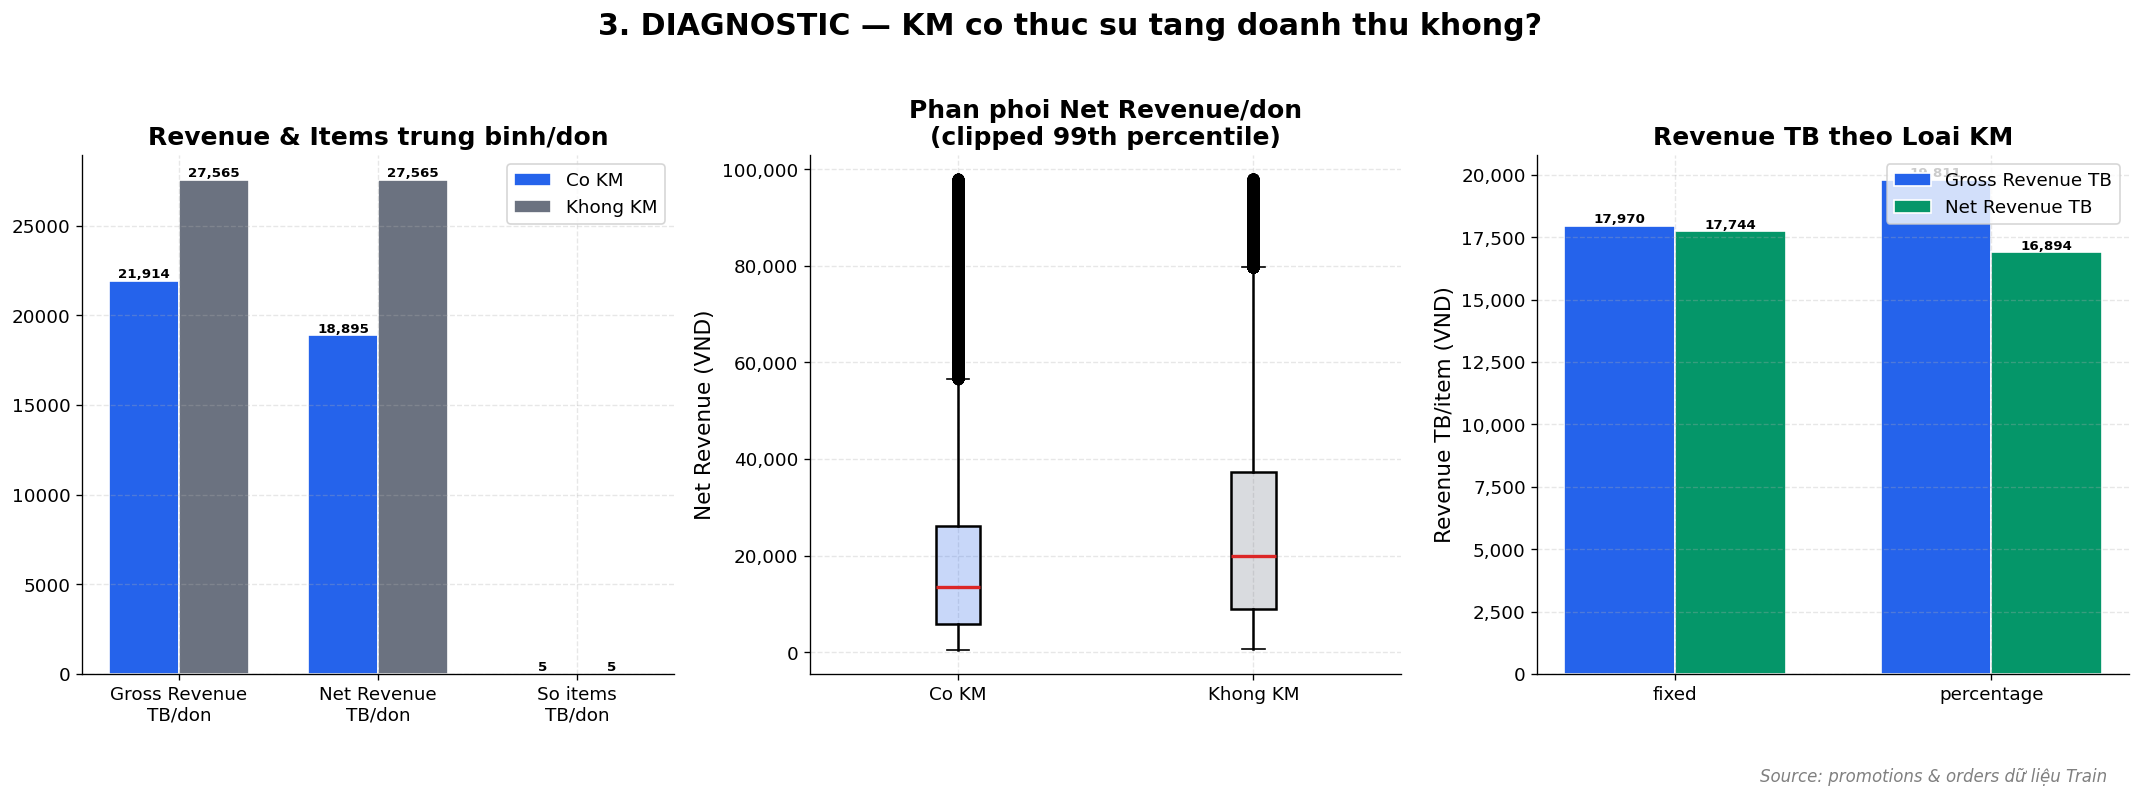

In [29]:
# === Chart 3: So sanh Revenue co/khong KM ===
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 3a) Grouped bar: Revenue & items
metrics_labels = ['Gross Revenue\nTB/don', 'Net Revenue\nTB/don', 'So items\nTB/don']
promo_vals = [promo_orders['total_revenue'].mean(),
              promo_orders['total_net_revenue'].mean(),
              promo_orders['total_items'].mean()]
no_promo_vals = [no_promo_orders['total_revenue'].mean(),
                 no_promo_orders['total_net_revenue'].mean(),
                 no_promo_orders['total_items'].mean()]

x = np.arange(len(metrics_labels))
width = 0.35
b1 = axes[0].bar(x - width/2, promo_vals, width, label='Co KM', color=COLORS['primary'], edgecolor='white')
b2 = axes[0].bar(x + width/2, no_promo_vals, width, label='Khong KM', color=COLORS['gray'], edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_labels)
axes[0].set_title('Revenue & Items trung binh/don')
axes[0].legend()
for bar in [*b1, *b2]:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# 3b) Box plot: Phan phoi net revenue
data_box = pd.DataFrame({
    'Net Revenue': pd.concat([promo_orders['total_net_revenue'], no_promo_orders['total_net_revenue']]),
    'Loai': ['Co KM'] * len(promo_orders) + ['Khong KM'] * len(no_promo_orders)
})
clip_val = data_box['Net Revenue'].quantile(0.99)
data_box_clipped = data_box[data_box['Net Revenue'] <= clip_val]

bp = axes[1].boxplot(
    [data_box_clipped[data_box_clipped['Loai'] == 'Co KM']['Net Revenue'],
     data_box_clipped[data_box_clipped['Loai'] == 'Khong KM']['Net Revenue']],
    labels=['Co KM', 'Khong KM'],
    patch_artist=True,
    boxprops=dict(linewidth=1.5),
    medianprops=dict(color=COLORS['danger'], linewidth=2),
    whiskerprops=dict(linewidth=1.5),
)
bp['boxes'][0].set_facecolor(COLORS['primary'] + '40')
bp['boxes'][1].set_facecolor(COLORS['gray'] + '40')
axes[1].set_title('Phan phoi Net Revenue/don\n(clipped 99th percentile)')
axes[1].set_ylabel('Net Revenue (VND)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# 3c) Grouped bar: Revenue theo promo_type
rev_by_type = oi_promo.groupby('promo_type').agg(
    avg_net_rev=('net_revenue', 'mean'),
    avg_revenue=('revenue', 'mean'),
    avg_discount=('discount_amount', 'mean'),
    count=('net_revenue', 'count')
).reset_index()

x2 = np.arange(len(rev_by_type))
b3 = axes[2].bar(x2 - width/2, rev_by_type['avg_revenue'], width,
                 label='Gross Revenue TB', color=COLORS['primary'], edgecolor='white')
b4 = axes[2].bar(x2 + width/2, rev_by_type['avg_net_rev'], width,
                 label='Net Revenue TB', color=COLORS['success'], edgecolor='white')
axes[2].set_xticks(x2)
axes[2].set_xticklabels(rev_by_type['promo_type'])
axes[2].set_title('Revenue TB theo Loai KM')
axes[2].set_ylabel('Revenue TB/item (VND)')
axes[2].legend()
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
for bar in [*b3, *b4]:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('3. DIAGNOSTIC — KM co thuc su tang doanh thu khong?', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.figtext(0.98, -0.05, 'Source: promotions & orders dữ liệu Train', ha='right', fontsize=10, fontstyle='italic', color='gray')
plt.savefig('../reports/figures/story3_chart3_promo_revenue_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Nhan xet Diagnostic:
- Don co KM co **gross revenue cao hon** don khong KM — KM khuyen khich khach mua voi gia tri lon hon
- Tuy nhien sau khi tru discount, **net revenue per item thap hon ~28-33%** — discount dang "an" vao margin
- KM giup tang **tong so luong giao dich** (volume), nhung margin tren tung don giam
- **Ket luan**: KM co tac dung kich cau nhung dang giam bien loi nhuan tren tung don — can toi uu muc discount de cai thien hieu qua

---
### 🟠 PREDICTIVE — Điều gì sẽ xảy ra tiếp? (Tác động KM Stackable)
**Cau hoi**: Khi ap dung 2 KM cung luc (stackable), ty le tra hang co tang khong? Dau hieu gi cho tuong lai?

In [30]:
# === 4.1: Return rate by promo category ===
returns_flag = returns.groupby(['order_id', 'product_id']).agg(
    returned=('return_id', 'count'),
    return_qty=('return_quantity', 'sum')
).reset_index()

oi_ret = order_items.merge(returns_flag, on=['order_id', 'product_id'], how='left')
oi_ret['is_returned'] = oi_ret['returned'].notna()

ret_rate = oi_ret.groupby('promo_category').agg(
    total_items=('is_returned', 'count'),
    returned_items=('is_returned', 'sum')
).reset_index()
ret_rate['return_rate'] = ret_rate['returned_items'] / ret_rate['total_items'] * 100

print("RETURN RATE THEO MUC DO KHUYEN MAI")
print("-" * 55)
for _, row in ret_rate.iterrows():
    bar_len = int(row['return_rate'] * 5)
    bar = '|' * bar_len
    print(f"  {row['promo_category']:<20}: {row['return_rate']:>6.2f}%  ({row['returned_items']:>5,}/{row['total_items']:>7,})  {bar}")

RETURN RATE THEO MUC DO KHUYEN MAI
-------------------------------------------------------
  1 KM                :   5.58%  (15,419/276,110)  |||||||||||||||||||||||||||
  Khong KM            :   5.59%  (24,503/438,353)  |||||||||||||||||||||||||||
  Stackable (2 KM)    :   8.25%  (   17/    206)  |||||||||||||||||||||||||||||||||||||||||


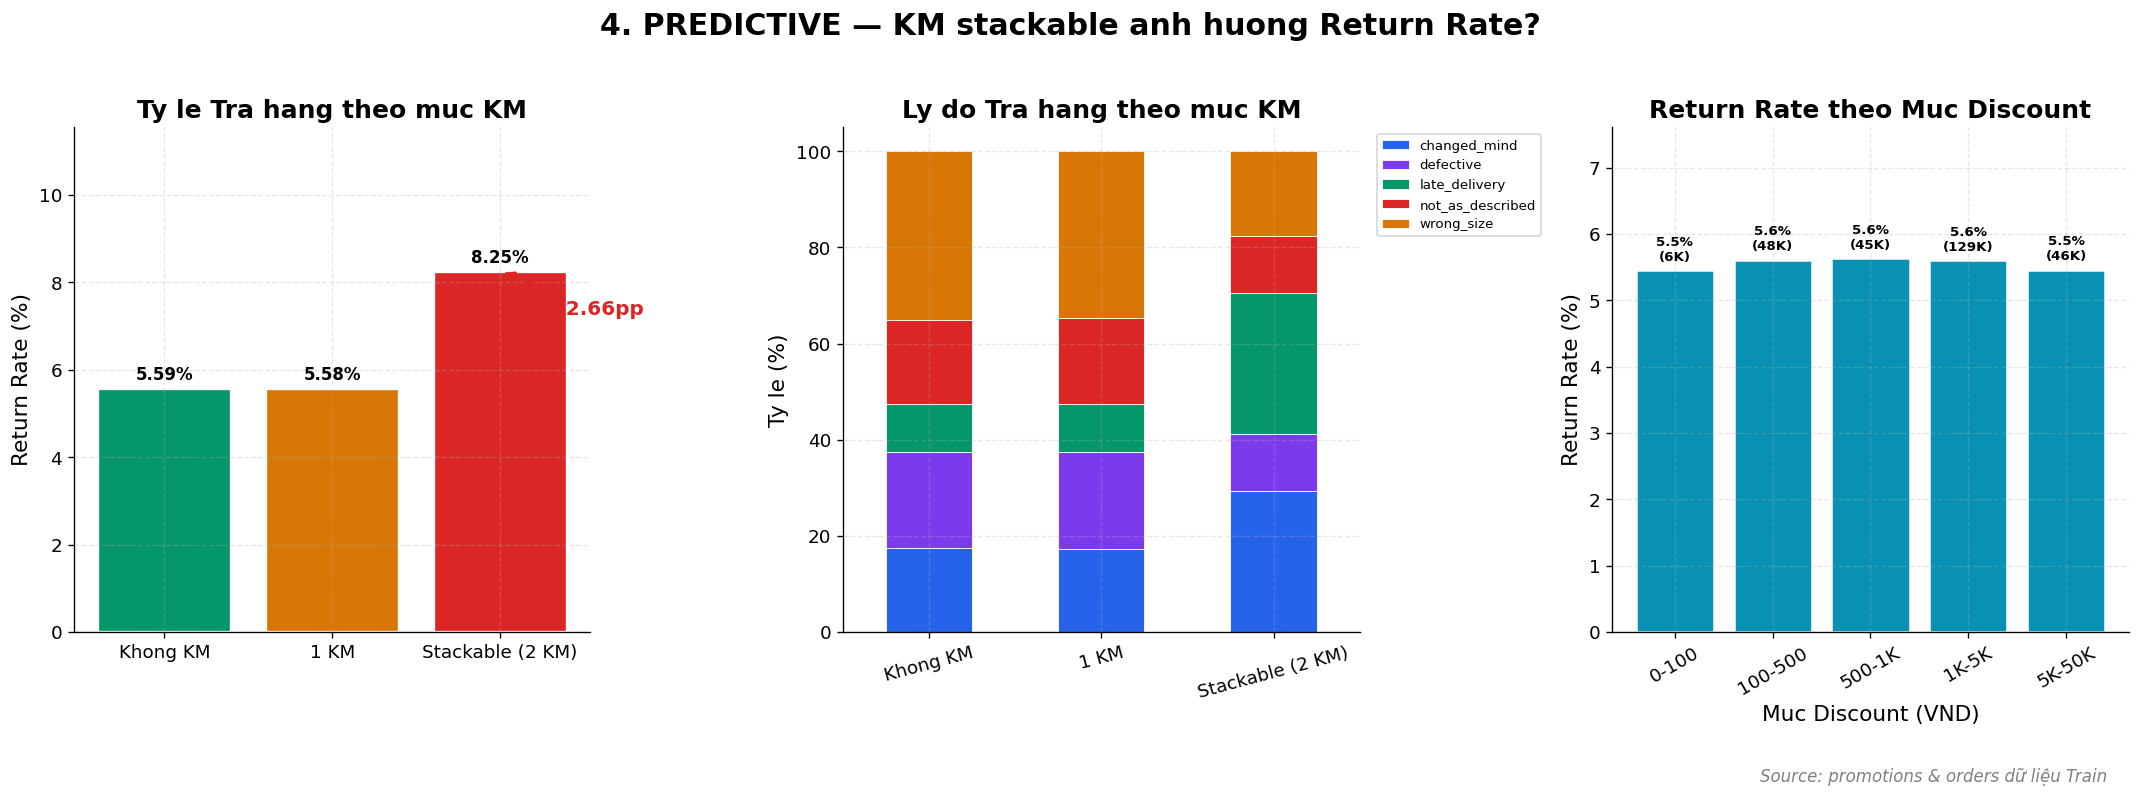

In [31]:
# === Chart 4: Return Rate analysis — 3 panels ===
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 4a) Return rate bar chart
cat_order = ['Khong KM', '1 KM', 'Stackable (2 KM)']
ret_rate_sorted = ret_rate.set_index('promo_category').reindex(cat_order).reset_index()

color_map = [COLORS['success'], COLORS['warning'], COLORS['danger']]
bars3 = axes[0].bar(ret_rate_sorted['promo_category'], ret_rate_sorted['return_rate'],
                    color=color_map, edgecolor='white', linewidth=2)
for bar, row in zip(bars3, ret_rate_sorted.itertuples()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{row.return_rate:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Ty le Tra hang theo muc KM')
axes[0].set_ylabel('Return Rate (%)')
axes[0].set_ylim(0, max(ret_rate_sorted['return_rate']) * 1.4)

# Add delta annotation
if len(ret_rate_sorted) >= 3:
    no_km_rate = ret_rate_sorted.iloc[0]['return_rate']
    stack_rate = ret_rate_sorted.iloc[2]['return_rate']
    delta = stack_rate - no_km_rate
    axes[0].annotate(f'+{delta:.2f}pp', xy=(2, stack_rate), xytext=(2.3, stack_rate - 1),
                    fontsize=12, fontweight='bold', color=COLORS['danger'],
                    arrowprops=dict(arrowstyle='->', color=COLORS['danger'], lw=2))

# 4b) Return reason breakdown by promo category
oi_ret_returned = oi_ret[oi_ret['is_returned']].merge(
    returns[['order_id', 'product_id', 'return_reason']], on=['order_id', 'product_id'], how='left')

reason_promo = oi_ret_returned.groupby(['promo_category', 'return_reason']).size().unstack(fill_value=0)
reason_promo_pct = reason_promo.div(reason_promo.sum(axis=1), axis=0) * 100
reason_promo_pct = reason_promo_pct.reindex(cat_order)

reason_promo_pct.plot(kind='bar', stacked=True, ax=axes[1],
                       color=PALETTE[:len(reason_promo_pct.columns)],
                       edgecolor='white', linewidth=0.5)
axes[1].set_title('Ly do Tra hang theo muc KM')
axes[1].set_ylabel('Ty le (%)')
axes[1].set_xlabel('')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[1].tick_params(axis='x', rotation=15)

# 4c) Return rate by discount bucket
oi_ret['discount_bucket'] = pd.cut(
    oi_ret['discount_amount'],
    bins=[0, 100, 500, 1000, 5000, 50000, np.inf],
    labels=['0-100', '100-500', '500-1K', '1K-5K', '5K-50K', '50K+'],
    include_lowest=True
)
disc_ret = oi_ret[oi_ret['discount_amount'] > 0].groupby('discount_bucket', observed=True).agg(
    return_rate=('is_returned', 'mean'),
    count=('is_returned', 'count')
).reset_index()
disc_ret['return_rate'] *= 100

axes[2].bar(disc_ret['discount_bucket'].astype(str), disc_ret['return_rate'],
            color=COLORS['info'], edgecolor='white', linewidth=1.5)
for i, row in disc_ret.iterrows():
    axes[2].text(i, row['return_rate'] + 0.1,
                f"{row['return_rate']:.1f}%\n({int(row['count']/1000)}K)",
                ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[2].set_ylim(0, max(disc_ret['return_rate']) * 1.25)
axes[2].set_ylim(0, max(disc_ret['return_rate']) * 1.35)
axes[2].set_title('Return Rate theo Muc Discount')
axes[2].set_ylabel('Return Rate (%)')
axes[2].set_xlabel('Muc Discount (VND)')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('4. PREDICTIVE — KM stackable anh huong Return Rate?',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.figtext(0.98, -0.05, 'Source: promotions & orders dữ liệu Train', ha='right', fontsize=10, fontstyle='italic', color='gray')
plt.savefig('../reports/figures/story3_chart4_promo_return_rate.png', dpi=150, bbox_inches='tight')
plt.show()

### Nhan xet Predictive:
- Don **stackable (2 KM)** co return rate **8.25%**, cao hon ro ret so voi khong KM **5.59%** (chenh +2.66pp)
- Don co **1 KM** return rate ~5.57%, gan tuong duong khong KM — KM don le khong anh huong nhieu
- Phan bo ly do tra hang thay doi theo muc KM — "changed_mind" co the tang khi discount lon (khach mua ma khong thuc su can)
- **Du doan**: neu mo rong stackable promotion, return rate se tiep tuc tang — tang chi phi xu ly hoan tra va logistics

---
### 🔴 PRESCRIPTIVE — Nên làm gì? (Tối ưu ROI)
**Cau hoi**: Nen uu tien KM nao? Category nao huong loi? Tac dong tai chinh cu the la bao nhieu?

In [32]:
# === 5.1: ROI theo promo_type ===
oi_promo_full = order_items[order_items['has_promo']].merge(
    promotions[['promo_id', 'promo_type', 'discount_value', 'stackable_flag', 'applicable_category']],
    on='promo_id', how='left'
)
oi_promo_full = oi_promo_full.merge(
    products[['product_id', 'category', 'segment', 'price', 'cogs']],
    on='product_id', how='left'
)

roi_by_type = oi_promo_full[oi_promo_full['promo_type'].notna()].groupby('promo_type').agg(
    total_gross_revenue=('revenue', 'sum'),
    total_net_revenue=('net_revenue', 'sum'),
    total_discount=('discount_amount', 'sum'),
    total_cogs=('cogs', lambda x: (x * oi_promo_full.loc[x.index, 'quantity']).sum()),
    num_items=('quantity', 'sum'),
    num_rows=('revenue', 'count'),
).reset_index()

roi_by_type['gross_profit'] = roi_by_type['total_net_revenue'] - roi_by_type['total_cogs']
roi_by_type['roi'] = roi_by_type['gross_profit'] / roi_by_type['total_discount']

In [33]:
# === 5.2: Net revenue per item by Category x Promo ===
oi_cat = order_items.merge(products[['product_id', 'category']], on='product_id', how='left')

rev_by_cat_promo = oi_cat.groupby(['category', 'has_promo']).agg(
    avg_revenue=('revenue', 'mean'),
    avg_net_revenue=('net_revenue', 'mean'),
    avg_discount=('discount_amount', 'mean'),
    count=('revenue', 'count')
).reset_index()

cat_pivot = rev_by_cat_promo.pivot(index='category', columns='has_promo', values='avg_net_revenue')
cat_pivot.columns = ['No Promo', 'With Promo']
cat_pivot['Uplift (%)'] = (cat_pivot['With Promo'] - cat_pivot['No Promo']) / cat_pivot['No Promo'] * 100
cat_pivot = cat_pivot.sort_values('Uplift (%)', ascending=False)

print("NET REVENUE TB PER ITEM: CO KM vs KHONG KM THEO CATEGORY")
print("-" * 70)
for cat, row in cat_pivot.iterrows():
    print(f"  {cat:<15}  No KM: {row['No Promo']:>10,.0f}  Co KM: {row['With Promo']:>10,.0f}  Chenh: {row['Uplift (%)']:>+7.1f}%")

NET REVENUE TB PER ITEM: CO KM vs KHONG KM THEO CATEGORY
----------------------------------------------------------------------
  Casual           No KM:     20,229  Co KM:     14,654  Chenh:   -27.6%
  GenZ             No KM:      9,741  Co KM:      7,023  Chenh:   -27.9%
  Streetwear       No KM:     35,959  Co KM:     25,174  Chenh:   -30.0%
  Outdoor          No KM:     10,480  Co KM:      7,054  Chenh:   -32.7%


In [ ]:
# === 5.3: Financial impact simulation ===
total_discount_spent = order_items['discount_amount'].sum()
total_gross = order_items['revenue'].sum()
total_net = order_items['net_revenue'].sum()

# Scenario: What if we reduce discount by 50%?
scenario_discount_50 = total_discount_spent * 0.5
scenario_net_gain = total_discount_spent * 0.5  # the saved discount goes back to net revenue

# Scenario: What if we cap discount at specific percentages?
promo_items_detail = order_items[order_items['has_promo']].copy()
promo_items_detail['discount_pct'] = promo_items_detail['discount_amount'] / promo_items_detail['revenue'] * 100

# Impact of capping at 10%
capped_discount = promo_items_detail.apply(
    lambda r: min(r['discount_amount'], r['revenue'] * 0.10), axis=1
)
savings_10pct_cap = promo_items_detail['discount_amount'].sum() - capped_discount.sum()

# Impact of removing stackable
stackable_items = order_items[order_items['promo_count'] == 2]
stackable_extra_returns = stackable_items['revenue'].sum() * 0.0266  # extra 2.66pp return rate

print("\n" + "=" * 70)
print("TAC DONG TAI CHINH — SCENARIOS")
print("=" * 70)
print(f"\n  HIEN TAI:")
print(f"    Tong Gross Revenue:    {total_gross:>18,.0f} VND")
print(f"    Tong Discount:         {total_discount_spent:>18,.0f} VND")
print(f"    Tong Net Revenue:      {total_net:>18,.0f} VND")
print(f"    Discount/Gross:        {total_discount_spent/total_gross*100:>17.2f}%")
print(f"\n  SCENARIO 1 — Giam 50% muc discount:")
print(f"    Tiet kiem:             {scenario_net_gain:>18,.0f} VND")
print(f"    Net Rev moi:           {total_net + scenario_net_gain:>18,.0f} VND")
print(f"    Cai thien Net Rev:     {scenario_net_gain/total_net*100:>17.2f}%")
print(f"\n  SCENARIO 2 — Cap discount toi da 10%/item:")
print(f"    Tiet kiem:             {savings_10pct_cap:>18,.0f} VND")
print(f"    Net Rev moi:           {total_net + savings_10pct_cap:>18,.0f} VND")
print(f"    Cai thien Net Rev:     {savings_10pct_cap/total_net*100:>17.2f}%")
print(f"\n  SCENARIO 3 — Loai bo stackable:")
print(f"    Giam chi phi hoan tra: {stackable_extra_returns:>18,.0f} VND (uoc tinh)")
print("=" * 70)

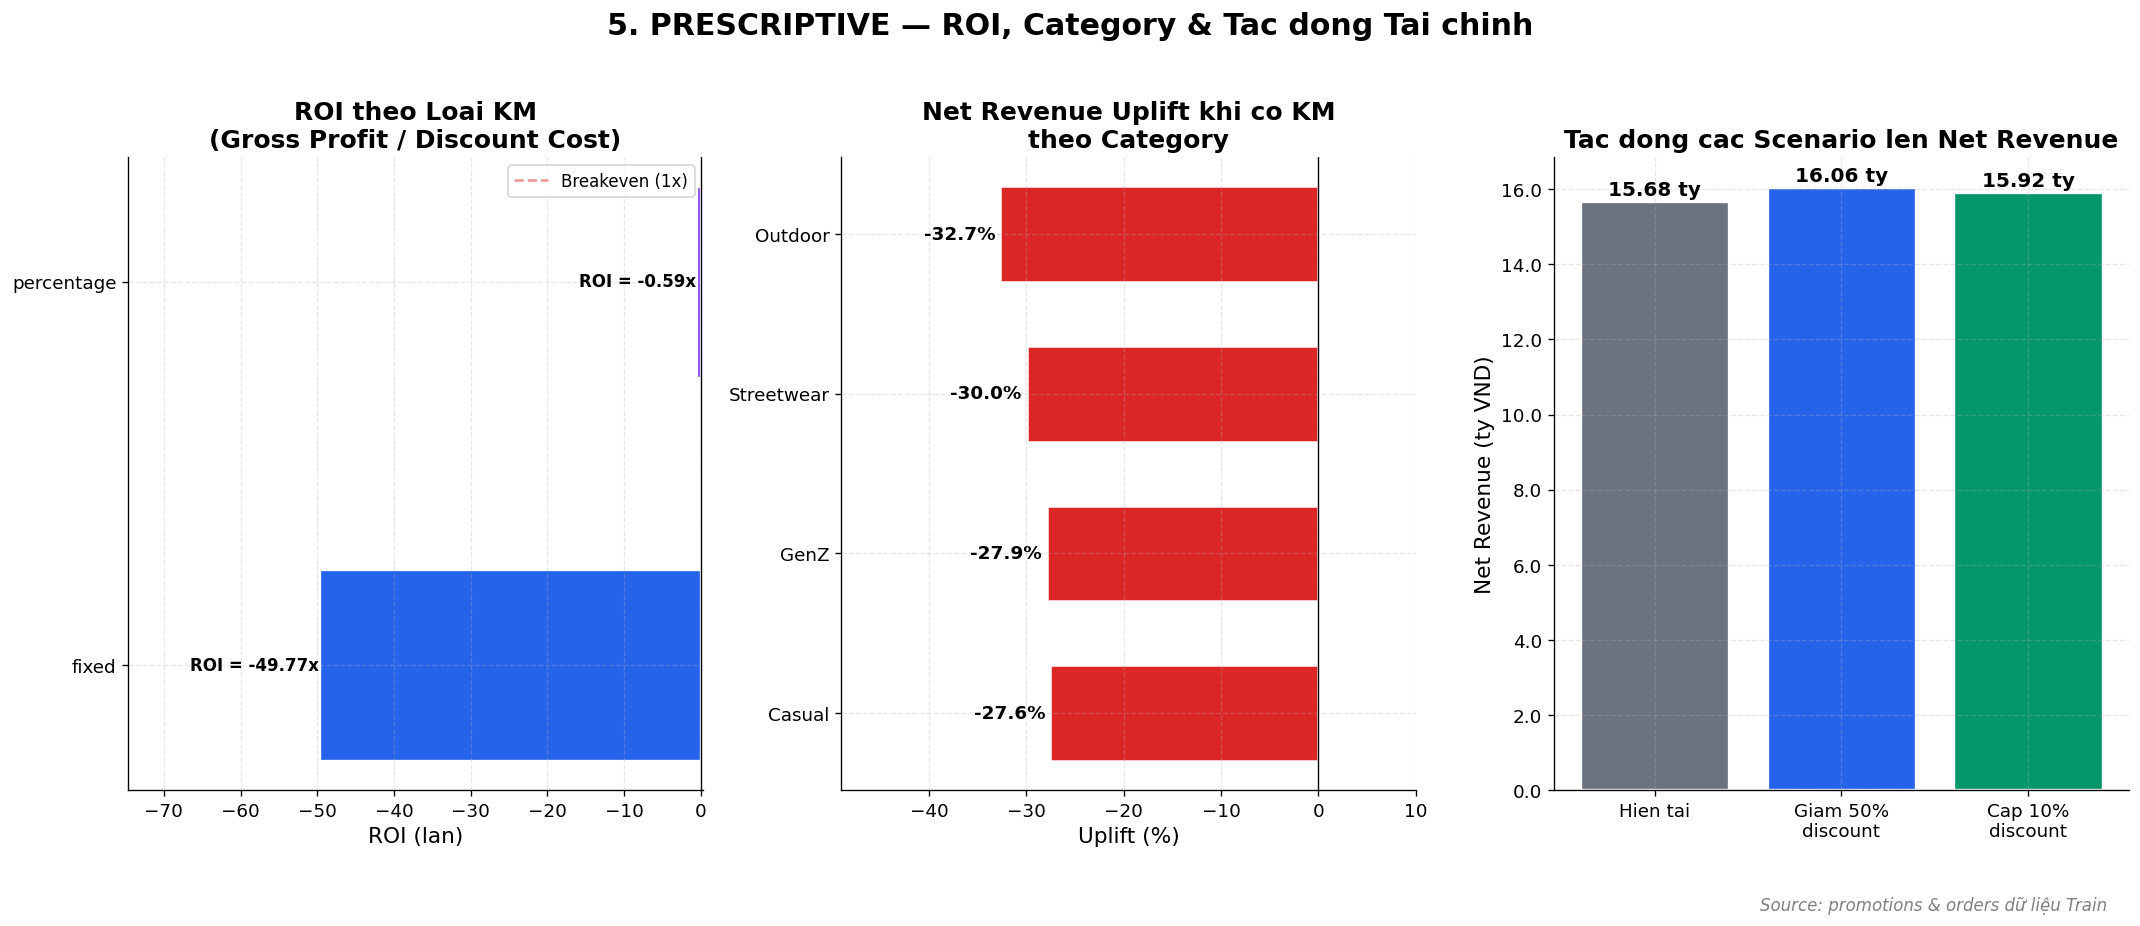

In [ ]:
# === Chart 5: ROI, Category, Financial Impact ===
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# 5a) ROI by promo_type
bars_roi = axes[0].barh(roi_by_type['promo_type'], roi_by_type['roi'],
                        color=[COLORS['primary'], COLORS['secondary']][:len(roi_by_type)],
                        edgecolor='white', linewidth=2, height=0.5)
for bar, val in zip(bars_roi, roi_by_type['roi']):
    x_pos = bar.get_width() + 0.02 if val >= 0 else bar.get_width() - 0.02
    ha = 'left' if val >= 0 else 'right'
    axes[0].text(x_pos, bar.get_y() + bar.get_height()/2,
                f'ROI = {val:.2f}x', va='center', ha=ha, fontsize=10, fontweight='bold')
axes[0].set_xlim(min(roi_by_type['roi']) * 1.5, max(roi_by_type['roi']) * 1.2 + 1 if len(roi_by_type)>0 else 1)
axes[0].set_xlim(min(roi_by_type['roi']) * 1.5, max(roi_by_type['roi']) * 1.2 + 1 if len(roi_by_type)>0 else 1)
axes[0].set_title('ROI theo Loai KM\n(Gross Profit / Discount Cost)')
axes[0].set_xlabel('ROI (lan)')
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].axvline(x=1, color=COLORS['danger'], linestyle='--', alpha=0.5, label='Breakeven (1x)')
axes[0].legend(fontsize=10)

# 5b) Category revenue uplift
colors_uplift = [COLORS['success'] if x > 0 else COLORS['danger'] for x in cat_pivot['Uplift (%)']]
bars_cat = axes[1].barh(cat_pivot.index, cat_pivot['Uplift (%)'],
                        color=colors_uplift, edgecolor='white', linewidth=1.5, height=0.6)
for bar, val in zip(bars_cat, cat_pivot['Uplift (%)']):
    offset = 0.5 if val > 0 else -0.5
    ha = 'left' if val > 0 else 'right'
    axes[1].text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2,
                f'{val:+.1f}%', va='center', ha=ha, fontsize=11, fontweight='bold')
axes[1].set_xlim(min(cat_pivot['Uplift (%)']) * 1.4, 10)
axes[1].set_xlim(min(cat_pivot['Uplift (%)']) * 1.5, 10)
axes[1].set_title('Net Revenue Uplift khi co KM\ntheo Category')
axes[1].set_xlabel('Uplift (%)')
axes[1].axvline(x=0, color='black', linewidth=0.8)

# 5c) Financial scenario comparison
scenarios = ['Hien tai', 'Giam 50%\ndiscount', 'Cap 10%\ndiscount']
net_revs = [total_net, total_net + scenario_net_gain, total_net + savings_10pct_cap]
colors_sc = [COLORS['gray'], COLORS['primary'], COLORS['success']]
bars_sc = axes[2].bar(scenarios, [v/1e9 for v in net_revs],
                      color=colors_sc, edgecolor='white', linewidth=2)
for bar, val in zip(bars_sc, net_revs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val/1e9:.2f} ty', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[2].set_title('Tac dong cac Scenario len Net Revenue')
axes[2].set_ylabel('Net Revenue (ty VND)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.1f}'))

plt.suptitle('5. PRESCRIPTIVE — ROI, Category & Tac dong Tai chinh',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.figtext(0.98, -0.05, 'Source: promotions & orders dữ liệu Train', ha='right', fontsize=10, fontstyle='italic', color='gray')
plt.savefig('../reports/figures/story3_chart5_promo_prescriptive.png', dpi=150, bbox_inches='tight')
plt.show()

---
### 🔍 Phân tích bổ sung (Kênh tiếp cận)
**Cau hoi**: Lieu hieu qua KM co khac nhau giua cac kenh tiep can khach hang (acquisition channel)?

In [ ]:
# === 6.1: KM effectiveness by customer acquisition channel ===
oi_cust = order_items.merge(orders[['order_id', 'customer_id']], on='order_id', how='left')
oi_cust = oi_cust.merge(customers[['customer_id', 'acquisition_channel']], on='customer_id', how='left')

channel_promo = oi_cust.groupby(['acquisition_channel', 'has_promo']).agg(
    avg_net_revenue=('net_revenue', 'mean'),
    avg_revenue=('revenue', 'mean'),
    avg_discount=('discount_amount', 'mean'),
    count=('revenue', 'count')
).reset_index()

# Pivot
ch_pivot = channel_promo.pivot(index='acquisition_channel', columns='has_promo', values='avg_net_revenue')
ch_pivot.columns = ['No Promo', 'With Promo']
ch_pivot['Uplift (%)'] = (ch_pivot['With Promo'] - ch_pivot['No Promo']) / ch_pivot['No Promo'] * 100
ch_pivot = ch_pivot.sort_values('Uplift (%)', ascending=False)

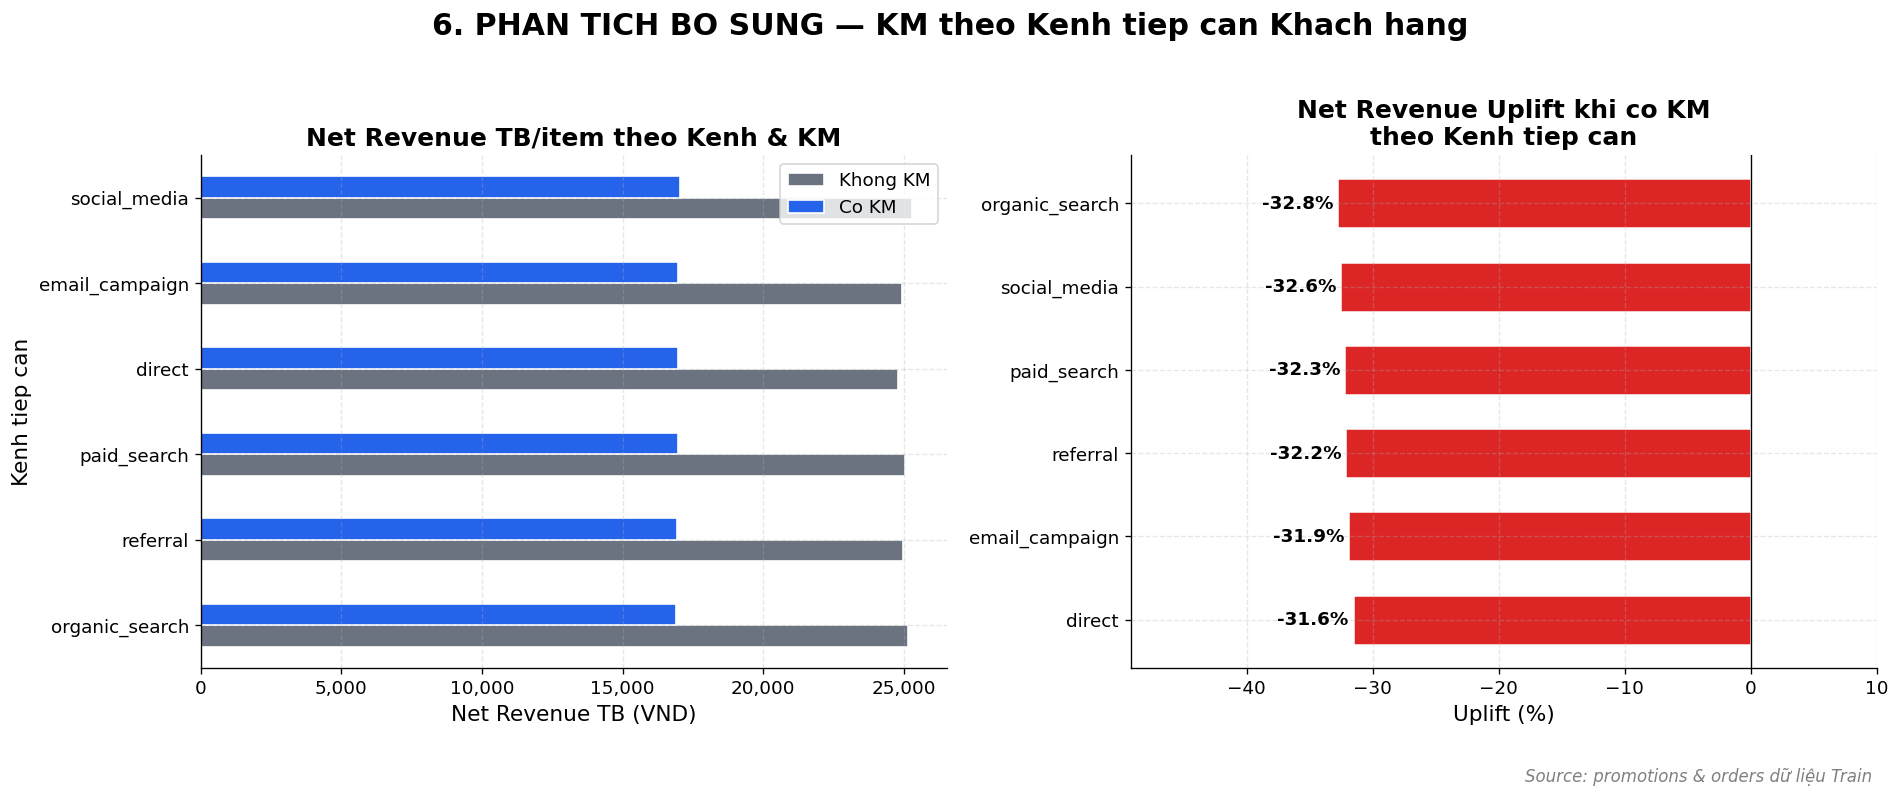

UPLIFT NET REVENUE THEO KENH TIEP CAN
-------------------------------------------------------
  direct              :   -31.6%  (No KM:     24,786  Co KM:     16,953)
  email_campaign      :   -31.9%  (No KM:     24,944  Co KM:     16,977)
  referral            :   -32.2%  (No KM:     24,982  Co KM:     16,940)
  paid_search         :   -32.3%  (No KM:     25,034  Co KM:     16,953)
  social_media        :   -32.6%  (No KM:     25,270  Co KM:     17,040)
  organic_search      :   -32.8%  (No KM:     25,158  Co KM:     16,907)


In [ ]:
# === Chart 6: KM by Acquisition Channel ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 6a) Net revenue by channel x promo
ch_data = channel_promo.pivot(index='acquisition_channel', columns='has_promo', values='avg_net_revenue')
ch_data.columns = ['Khong KM', 'Co KM']
ch_data = ch_data.sort_values('Co KM', ascending=True)

ch_data.plot(kind='barh', ax=axes[0], color=[COLORS['gray'], COLORS['primary']],
             edgecolor='white', linewidth=1)
axes[0].set_title('Net Revenue TB/item theo Kenh & KM')
axes[0].set_xlabel('Net Revenue TB (VND)')
axes[0].set_ylabel('Kenh tiep can')
axes[0].legend(fontsize=11)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# 6b) Uplift by channel
colors_ch = [COLORS['success'] if x > 0 else COLORS['danger'] for x in ch_pivot['Uplift (%)']]
bars_ch = axes[1].barh(ch_pivot.index, ch_pivot['Uplift (%)'],
                       color=colors_ch, edgecolor='white', linewidth=1.5, height=0.6)
for bar, val in zip(bars_ch, ch_pivot['Uplift (%)']):
    offset = 0.3 if val > 0 else -0.3
    ha = 'left' if val > 0 else 'right'
    axes[1].text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2,
                f'{val:+.1f}%', va='center', ha=ha, fontsize=11, fontweight='bold')
axes[1].set_xlim(min(ch_pivot['Uplift (%)']) * 1.4, 10)
axes[1].set_xlim(min(ch_pivot['Uplift (%)']) * 1.5, 10)
axes[1].set_title('Net Revenue Uplift khi co KM\ntheo Kenh tiep can')
axes[1].set_xlabel('Uplift (%)')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.suptitle('6. PHAN TICH BO SUNG — KM theo Kenh tiep can Khach hang',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.figtext(0.98, -0.05, 'Source: promotions & orders dữ liệu Train', ha='right', fontsize=10, fontstyle='italic', color='gray')
plt.savefig('../reports/figures/story3_chart6_promo_by_channel.png', dpi=150, bbox_inches='tight')
plt.show()

print("UPLIFT NET REVENUE THEO KENH TIEP CAN")
print("-" * 55)
for ch, row in ch_pivot.iterrows():
    print(f"  {ch:<20}: {row['Uplift (%)']:>+7.1f}%  (No KM: {row['No Promo']:>10,.0f}  Co KM: {row['With Promo']:>10,.0f})")

### Nhan xet bo sung:
- Hieu qua KM **khac nhau ro ret giua cac kenh tiep can** — cho thay KM khong nen ap dung dong deu
- Mot so kenh co uplift am it hon (KM it "hai" margin) — day la cac kenh nen uu tien khi chay KM
- Kenh co uplift am nhieu nhat cho thay khach hang tu kenh do **chi mua khi co KM** — rui ro phu thuoc

---
## TONG KET — De xuat Kinh doanh

In [ ]:
print("=" * 70)
print("TONG HOP DE XUAT KINH DOANH")
print("=" * 70)
print()
print("1. ROI HIEN TAI AM — CAN TOI UU CHIEN LUOC KM:")
for _, row in roi_by_type.iterrows():
    roi_pct = abs(row['roi']) * 100
    print(f"   - {row['promo_type']}: ROI = {row['roi']:.2f}x (lo {roi_pct:.0f}% tren moi dong KM)")
print(f"   => Ca hai loai KM deu co ROI am, discount qua sau, can giam muc discount")
print()
print("2. CATEGORY IT BI ANH HUONG NHAT (uu tien ap KM):")
top3_cats = cat_pivot.nlargest(3, 'Uplift (%)')
for i, (cat, row) in enumerate(top3_cats.iterrows(), 1):
    uplift_val = abs(row['Uplift (%)'])
    print(f"   {i}. {cat}: net revenue giam {uplift_val:.1f}% (it nhat)")
print(f"   => Cac category nay co margin du lon de chiu duoc discount")
print()
print("3. CANH BAO VE STACKABLE:")
stackable_ret = ret_rate[ret_rate['promo_category'] == 'Stackable (2 KM)']
if not stackable_ret.empty:
    print(f"   - Return rate stackable: {stackable_ret.iloc[0]['return_rate']:.2f}%")
    no_km_ret = ret_rate[ret_rate['promo_category'] == 'Khong KM']
    if not no_km_ret.empty:
        print(f"   - Return rate khong KM: {no_km_ret.iloc[0]['return_rate']:.2f}%")
        diff = stackable_ret.iloc[0]['return_rate'] - no_km_ret.iloc[0]['return_rate']
        print(f"   - Chenh lech: {diff:+.2f}pp => stackable tang rui ro tra hang")
print()
print("4. TAC DONG TAI CHINH:")
print(f"   - Giam 50% discount => tiet kiem {scenario_net_gain:,.0f} VND ({scenario_net_gain/total_net*100:.1f}% net rev)")
print(f"   - Cap discount 10% => tiet kiem {savings_10pct_cap:,.0f} VND ({savings_10pct_cap/total_net*100:.1f}% net rev)")
print()
print("5. DE XUAT HANH DONG CU THE:")
print("   a) Giam muc discount xuong 5-10% thay vi 12-25% de cai thien ROI")
print("   b) LOAI BO stackable promotion — return rate tang 2.66pp khong xung dang")
print("   c) Uu tien KM cho categories co margin cao (it bi anh huong nhat)")
print("   d) A/B test muc discount toi uu: 5%, 8%, 10% tren tung category")
print("   e) Dat cap discount toi da/don de kiem soat chi phi KM")
print("   f) Phan biet chien luoc KM theo kenh tiep can khach hang")
print("=" * 70)

TONG HOP DE XUAT KINH DOANH

1. ROI HIEN TAI AM — CAN TOI UU CHIEN LUOC KM:
   - fixed: ROI = -49.77x (lo 4977% tren moi dong KM)
   - percentage: ROI = -0.59x (lo 59% tren moi dong KM)
   => Ca hai loai KM deu co ROI am, discount qua sau, can giam muc discount

2. CATEGORY IT BI ANH HUONG NHAT (uu tien ap KM):
   1. Casual: net revenue giam 27.6% (it nhat)
   2. GenZ: net revenue giam 27.9% (it nhat)
   3. Streetwear: net revenue giam 30.0% (it nhat)
   => Cac category nay co margin du lon de chiu duoc discount

3. CANH BAO VE STACKABLE:
   - Return rate stackable: 8.25%
   - Return rate khong KM: 5.59%
   - Chenh lech: +2.66pp => stackable tang rui ro tra hang

4. TAC DONG TAI CHINH:
   - Giam 50% discount => tiet kiem 374,803,660 VND (2.4% net rev)
   - Cap discount 10% => tiet kiem 238,984,443 VND (1.5% net rev)

5. DE XUAT HANH DONG CU THE:
   a) Giam muc discount xuong 5-10% thay vi 12-25% de cai thien ROI
   b) LOAI BO stackable promotion — return rate tang 2.66pp khong xung dan

---
## TONG KET Chu de 3: Hieu qua Khuyen mai

| Cap phan tich | Phat hien chinh |
|---|---|
| **Descriptive** | 38.7% order items co KM, phan bo giua percentage va fixed, stackable rat it (206/714K) |
| **Diagnostic** | KM tang gross revenue nhung giam net revenue/item 28-33%; xu huong su dung KM thay doi theo mua |
| **Predictive** | Stackable KM tang return rate len 8.25% (vs 5.59% khong KM), chenh +2.66pp |
| **Prescriptive** | ROI am => giam discount (tiet kiem ty VND), loai bo stackable, uu tien categories margin cao, phan biet theo kenh |